In [37]:
from ultralytics import YOLO
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

import cv2
import numpy as np
import matplotlib.pyplot as plt


## YOLO

In [ ]:
model = YOLO("yolo11n-seg.pt")
results = model.predict("japancity.jpg", 
                        conf=0.01, # dont care about what object is
                        iou=0.1, # lower value reduce duplicates
                        max_det=100, 
                        imgsz=2048,# higher for better seg
                        show=True)


image 1/1 /Users/akshatmundra/Desktop/RPGPixelify/japancity.jpg: 1376x2048 6 persons, 2 bicycles, 1 car, 1 train, 1 truck, 1 traffic light, 1 bench, 1 handbag, 1 sports ball, 5 potted plants, 1 microwave, 10 clocks, 565.7ms
Speed: 11.1ms preprocess, 565.7ms inference, 99.5ms postprocess per image at shape (1, 3, 1376, 2048)


YOLO is object classification. What if we want to segment anything? Here comes SAM: you can place a point on an object and it'll come up with mask. So to get all the masks place a bunch of points. Meta has something that already does this: an auto-mask generator.  

## SAM

In [38]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [40]:
image = cv2.imread("japancity.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image)

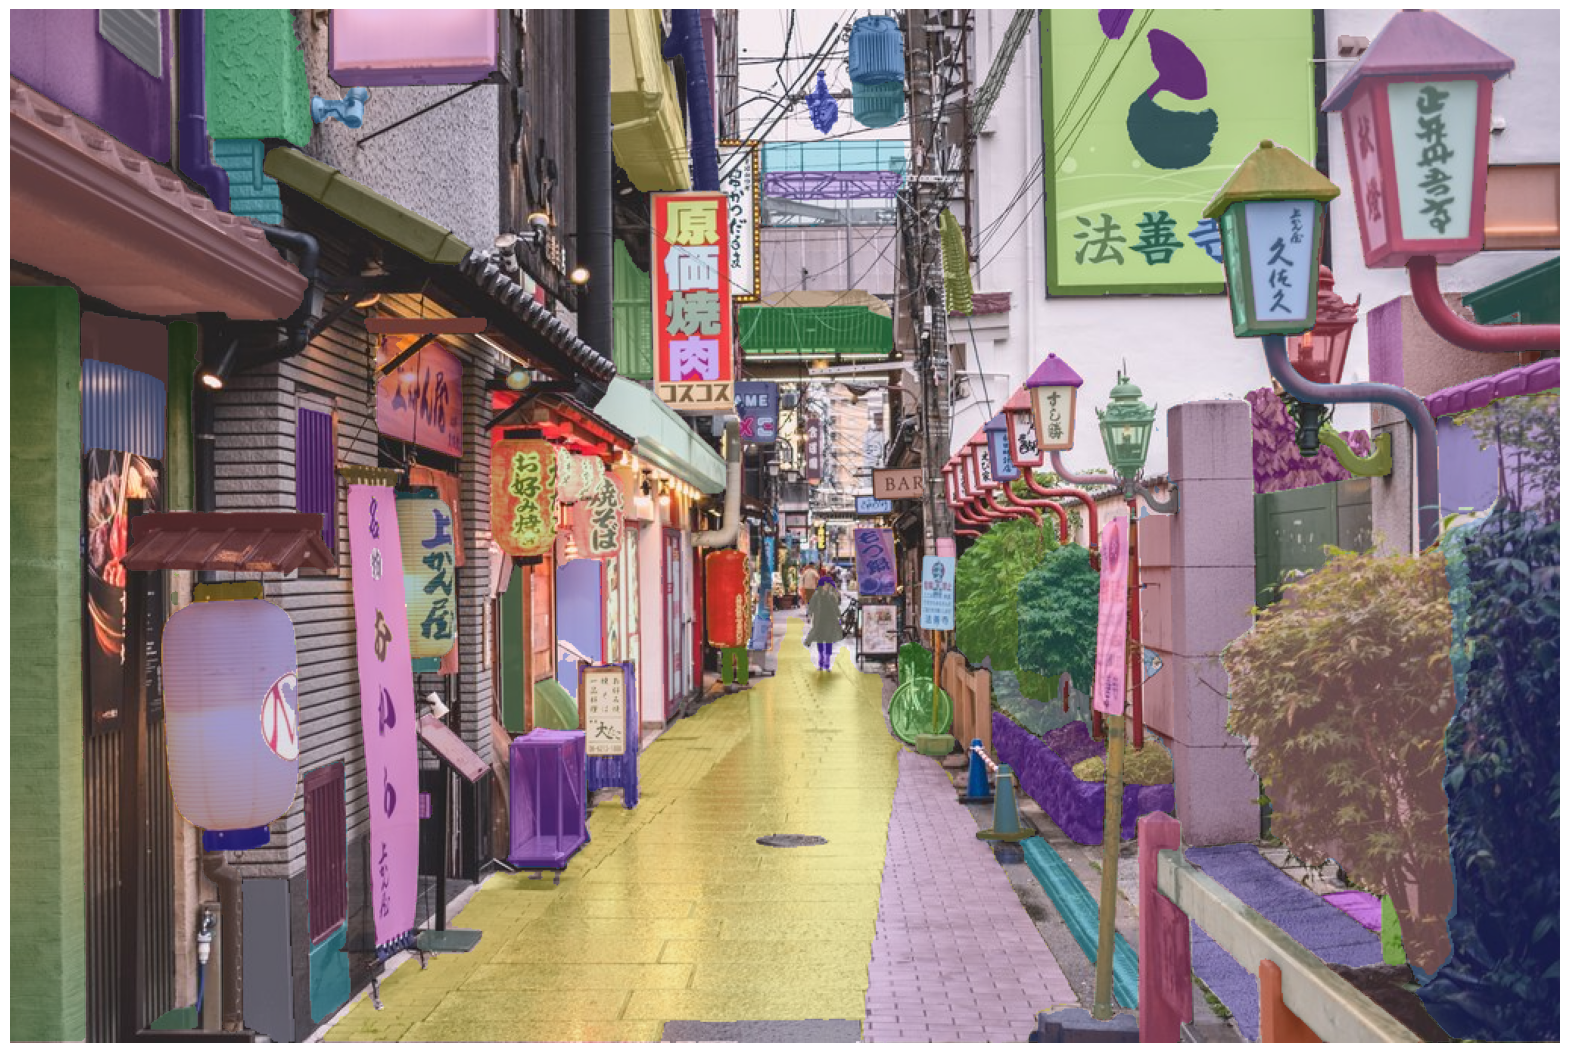

: 

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show() 